Module: Deep learning<br>
Lab: 4<br>
Name: Chun-Yuan Chen<br>

# Convolutions

In this lab, we'll look in detail at convolutions and how they can be used to process images.

### Reading and opening images

We'll use the `skimage` library to read and process images. It's a library dedicated to image processing, which is part of the `scikit-learn` family.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import skimage

sample image shape:  (400, 600, 3)


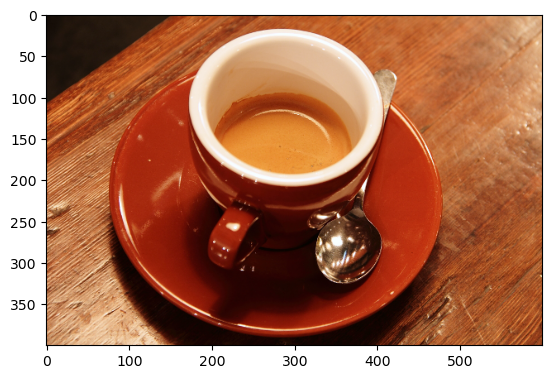

In [2]:
sample_image = skimage.data.coffee() # returns a sample image of a coffee cup

size = sample_image.shape
print("sample image shape: ", sample_image.shape)

plt.imshow(sample_image.astype('uint8')); 
    # CYC notes (ref: https://medium.com/@dineshbodigadla/whats-inside-an-image-a-simple-guide-to-pixels-channels-and-alpha-layers-66ae17ff50f7): 
        # uint8: the usual way pictures are stored and displayed.
        # Every pixel in this image has three numbers (one for red, one for green, one for blue).
        # Each number goes from 0 (none of that color) to 255 (full brightness).
        # Mixing these three colors in different amounts can create a range of different colors.
            # (255, 0, 0): bright red
            # (0, 255, 0): bright green
            # (0, 0, 255): bright blue
            # (255, 255, 255): white
            # (0, 0, 0): black

### A simple convolution filter

Before we start working on training any models, let's look at applying a convolution filter to an image. We'll use the `Conv2D` layer from Keras to do this.

In [3]:
from tensorflow.keras.layers import Conv2D
    # CYC notes:
        # looks at smaller parts of an image (e.g., 3×3 or 5×5 pixel blocks).
        # in order to learns specific patterns, e.g., 
            # edges--where the color/brightness changes suddenly
            # shapes--form/outline
            # textures--repeating patterns/surface details

In [4]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same")
    # filters=3: three filters
    # kernel_size=(5, 5): look at small 5*5 pixel blocks
    # padding="same": Keep the output size the same as the input size by adding padding around the edges
        # Ref: https://stackoverflow.com/questions/37674306/what-is-the-difference-between-same-and-valid-padding-in-tf-nn-max-pool-of-t

Remember: in Keras, `None` is used as a marker for tensor dimensions with dynamic size. In this case `batch_size`, `width` and `height` are all dynamic: they can depend on the input. This is a neat feature of convolutional neural networks: the same model can be used to process images of any size, because all we have to do is slide the convolutional filter across the image as much as necessary.

In [5]:
sample_image.shape

(400, 600, 3)

In [6]:
img_in = np.expand_dims(sample_image, 0).astype(float)
    # Adds a new dimension to (height, width, channels) >>> (1 image, height, width, channels).
    # Then, converts all the pixel values to floating-point numbers.
img_in.shape

(1, 400, 600, 3)

In [7]:
img_out = conv(img_in) # Apply the convolutional filter

The output is a tensorflow Eager Tensor - a special data structure that is used to represent the result of operations in TensorFlow. It is not a numpy array, but it can be converted to one using the `.numpy()` method:

In [8]:
np_img_out = img_out[0].numpy() # Now only 1 image, so takes the first image.
print(type(np_img_out))
print(np_img_out.shape)

<class 'numpy.ndarray'>
(400, 600, 3)


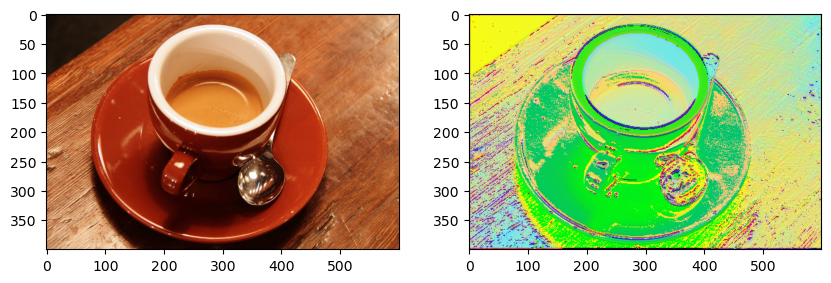

In [9]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(sample_image.astype('uint8')) # original image on the left
ax1.imshow(np_img_out.astype('uint8'));  # processed (e.g., after going through a layer) image on the right

As we can see, our convolutional filter was initialized randomly, so our output doesn't contain any specific meaning. Each pixel is a random combination of the pixels in the input image, in a 5x5 window.

Let's instead take a look at a convolutional feature with a clear purpose. We can build a kernel ourselves, by defining a function which will be passed to `Conv2D` Layer.
We'll create an array with 1/25 for filters, with each channel seperated. Before you move to the next cell, can you guess what this filter will do?

In [10]:
# A mean filter: way to blur an image
    # instead of keeping the original pixel, replace it with the average of its neighbors.

def my_kernel(shape=(5, 5, 3, 3), dtype=None):
    # filter size: 5×5 pixels
    # input channels: 3 (RGB)
    # output filters: 3 (one for each color)

    array = np.zeros(shape=shape, dtype="float32")

    # 1 / 25: gives each position the same value, so it averages the 25 pixels (multiplies each pixel in the 5×5 area by 1/25, then adds them up).
    array[:, :, 0, 0] = 1 / 25 # sets the values for the R filter
    array[:, :, 1, 1] = 1 / 25 # sets the values for the G filter
    array[:, :, 2, 2] = 1 / 25 # sets the values for the B filter

    return array

Now we can use this function to initialize a `Conv2D` layer:

In [11]:
conv = Conv2D(filters=3, kernel_size=(5, 5), padding="same", kernel_initializer=my_kernel)
    # Instead of random filters, here using the custom blur kernel: my_kernel.

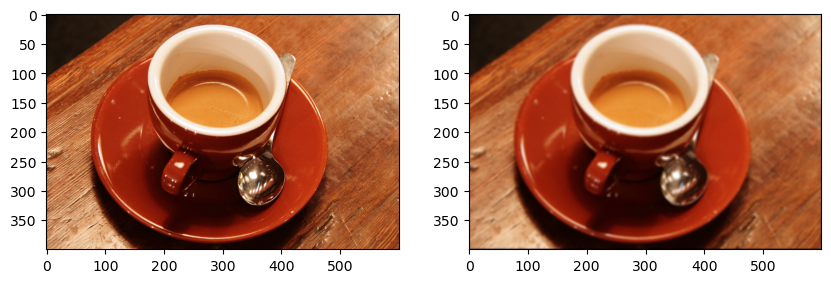

In [12]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(10, 5))
ax0.imshow(img_in[0].astype('uint8'))

img_out = conv(img_in)
np_img_out = img_out[0].numpy()
ax1.imshow(np_img_out.astype('uint8'));

Hopefully you can tell what this filter does!

**Exercise**
- There are a number of settings when we define our Conv2D layer. Try changing the following parameters to get a sense of how they impact the result:
- kernel_size: try different sizes
- padding: try 'valid' instead of 'same' (hint: this may change the size of the output)

<class 'numpy.ndarray'>
(400, 600, 3)
<class 'numpy.ndarray'>
(400, 600, 3)


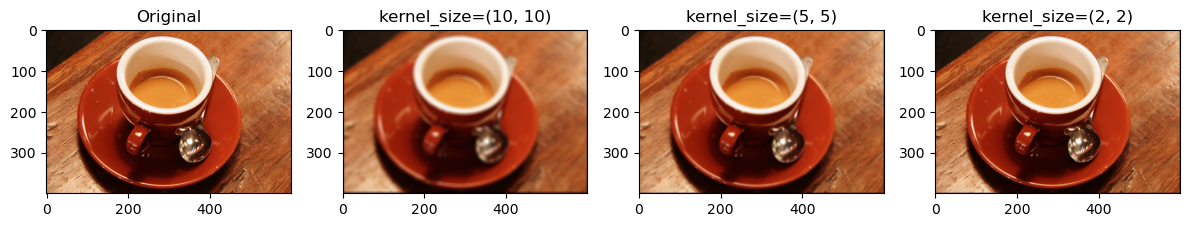

In [13]:
# Your Code Here

# Experiment 1: comparing with different kernel sizes
def my_kernel2(shape=(10, 10, 3, 3), dtype=None):
    array = np.zeros(shape=shape, dtype="float32")
    array[:, :, 0, 0] = 1 / 100
    array[:, :, 1, 1] = 1 / 100
    array[:, :, 2, 2] = 1 / 100
    return array

img_in2 = np.expand_dims(sample_image, 0).astype(float)
conv2 = Conv2D(filters=3, kernel_size=(10, 10), padding="same", kernel_initializer=my_kernel2)
img_out2 = conv2(img_in2) 
np_img_out2 = img_out2[0].numpy()
print(type(np_img_out2))
print(np_img_out2.shape)


def my_kernel3(shape=(2, 2, 3, 3), dtype=None):
    array = np.zeros(shape=shape, dtype="float32")
    array[:, :, 0, 0] = 1 / 4
    array[:, :, 1, 1] = 1 / 4
    array[:, :, 2, 2] = 1 / 4
    return array

img_in3 = np.expand_dims(sample_image, 0).astype(float)
conv3 = Conv2D(filters=3, kernel_size=(2, 2), padding="same", kernel_initializer=my_kernel3)
img_out3 = conv3(img_in3) 
np_img_out3 = img_out3[0].numpy()
print(type(np_img_out3))
print(np_img_out3.shape)

fig2, (ax0, ax1, ax2, ax3) = plt.subplots(ncols=4, figsize=(12, 3))

ax0.imshow(sample_image.astype('uint8'))       
ax0.set_title("Original")

ax1.imshow(np_img_out2.astype('uint8'))
ax1.set_title("kernel_size=(10, 10)")

ax2.imshow(np_img_out.astype('uint8'))         
ax2.set_title("kernel_size=(5, 5)")

ax3.imshow(np_img_out3.astype('uint8'))       
ax3.set_title("kernel_size=(2, 2)")

plt.tight_layout()
plt.show()

> CYC notes:<br>
>
> From the above four figures:<br>
>
> (1) Larger kernels blend a wider area of pixels >>> leads to stronger smoothing.<br> 
>
> (2) Smaller kernels focus on a narrower area of pixels >>> keep more the image closer to its original form.

In [14]:
# Experiment 2: comparing diff b/w 'valid' padding and 'same' padding 
print(type(np_img_out2)) # have been coded in the above code cell.
print(np_img_out2.shape) # have been coded in the above code cell.

img_in4 = np.expand_dims(sample_image, 0).astype(float)
conv4 = Conv2D(filters=3, kernel_size=(10, 10), padding="valid", kernel_initializer=my_kernel2)
img_out4 = conv4(img_in4) 
np_img_out4 = img_out4[0].numpy()
print(type(np_img_out4))
print(np_img_out4.shape)

<class 'numpy.ndarray'>
(400, 600, 3)
<class 'numpy.ndarray'>
(391, 591, 3)


> CYC notes:<br>
>
> From the above output:<br>
>
> So with 'valid' padding, the output image becomes smaller (400, 600, 3) to (391, 591, 3) because the filter skips the edges.
>
> In other words, the filter window stays inside the image for 'valid' padding; for the 'same' approach, the output is the same size. 
>
> Ref: https://stackoverflow.com/questions/37674306/what-is-the-difference-between-same-and-valid-padding-in-tf-nn-max-pool-of-t


### Working on edge detection on Grayscale image

Using a grayscale image, let's build an "edge detector" using a convolutional filter. Some filters pre-date the deep learning era and are still used today. For example, the Sobel filter is used to detect edges in images. These easy-to-compute filters were used in the early days of computer vision and are still useful now.

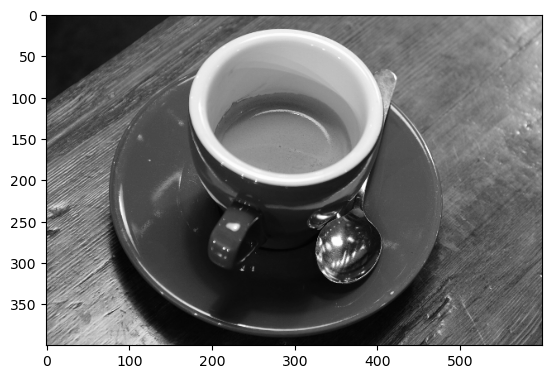

In [15]:
# convert image to greyscale
    # averages the RGB values for each pixel >>> collapses these 3 values into a single number >>> the average brightness (grayscale intensity) for each pixel 
    # axis=2 indicates channel
grey_sample_image = sample_image.mean(axis=2)

# add the channel dimension even if it's only one channel so
# to be consistent with Keras expectations.
grey_sample_image = grey_sample_image[:, :, np.newaxis]

# matplotlib does not like the extra dim for the color channel
# when plotting gray-level images. Let's use squeeze:
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray);

**Exercise**
- Build an edge detector using `Conv2D` on greyscale image by defining the kernel inside `my_kernel`.
- You may experiment with several kernels to find a way to detect edges. The following article contains specific examples of kernels that you can use:
- https://en.wikipedia.org/wiki/Kernel_(image_processing)
- Try different kernels and see the impact on the output.

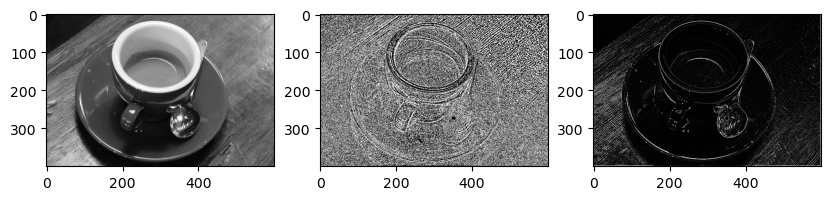

In [16]:
def my_kernel(shape=(3, 3, 1, 1), dtype=None):

    kernel_2d = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ], dtype='float32')

    array = kernel_2d[:, :, np.newaxis, np.newaxis]

    return array

conv = Conv2D(filters=1, kernel_size=(3, 3), padding="same", kernel_initializer=my_kernel)

img_in = np.expand_dims(grey_sample_image, 0) # Reshape into a batch of size 1
img_out = conv(img_in) # Apply the convolutional filter
np_img_out = img_out[0].numpy() # Convert to numpy array

fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(10, 5))
ax0.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray)          # original grayscale
ax1.imshow(np_img_out.astype(np.uint8), cmap=plt.cm.gray)                             # raw (not clipped) convolution output
ax2.imshow(np.clip(np_img_out.squeeze(), 0, 255).astype(np.uint8), cmap=plt.cm.gray); # clipped convolution output. CYC: I added this to compare not clipped to clipped.

### Pooling and strides with convolutions

**Exercise**
- Use `MaxPool2D` to apply a 2x2 max pool with strides 2 to the image. What is the impact on the shape of the image?
- Use `AvgPool2D` to apply an average pooling.
- Is it possible to compute a max pooling and an average pooling with well chosen kernels?

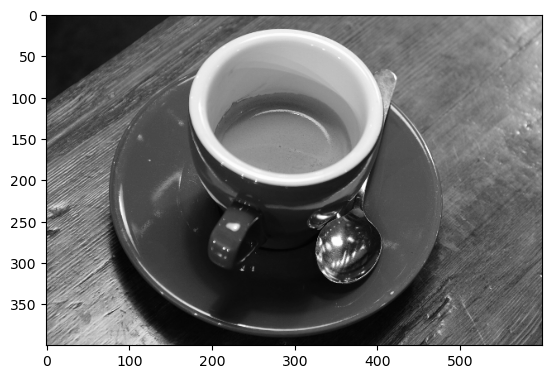

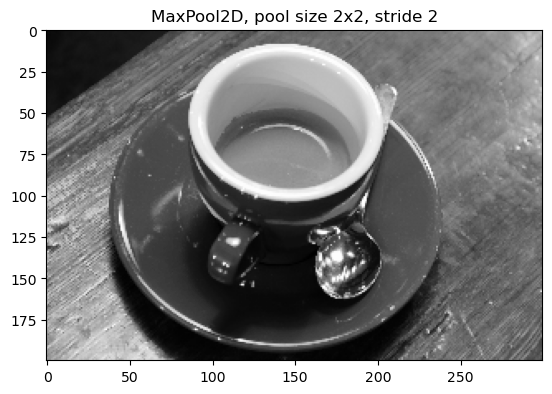

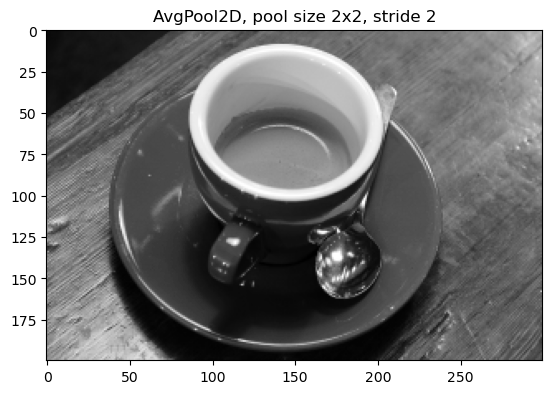

In [17]:
from tensorflow.keras.layers import MaxPool2D, AvgPool2D

# You can use `img_in` from above as input to the pooling layers

plt.figure()
plt.imshow(np.squeeze(grey_sample_image.astype(np.uint8)), cmap=plt.cm.gray);

# pool = MaxPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")
pool = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.title("MaxPool2D, pool size 2x2, stride 2")
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)), cmap=plt.cm.gray);

# pool = AvgPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")
pool = AvgPool2D(pool_size=(2, 2), strides=(2, 2), padding="valid")

img_out = pool(img_in)
np_img_out = img_out[0].numpy()

plt.figure()
plt.title("AvgPool2D, pool size 2x2, stride 2")
plt.imshow(np.squeeze(np_img_out.astype(np.uint8)), cmap=plt.cm.gray);

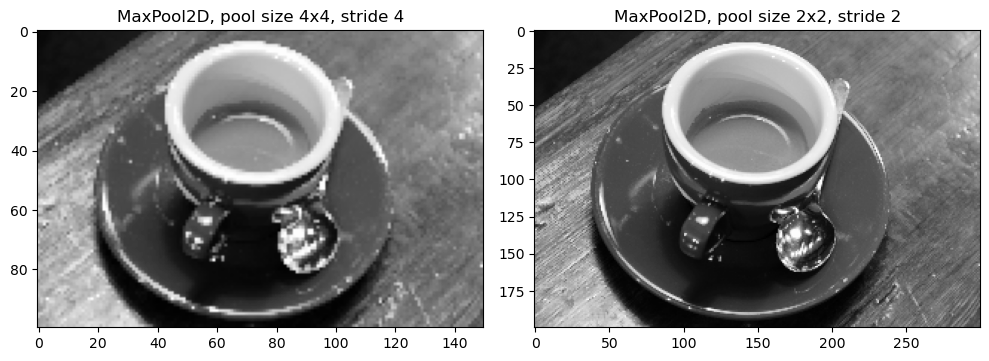

In [18]:
# CYC: I put two figures MaxPool2D with pool_size=(4, 4), strides=(4, 4) and with pool_size=(2, 2), strides=(2, 2) side by side to have a visual comparison

pool_MaxPool2D_4 = MaxPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")
pool_MaxPool2D_2 = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding="valid")

img_out_MP4 = pool_MaxPool2D_4(img_in)
img_out_MP2 = pool_MaxPool2D_2(img_in)

np_img_out_MP4 = img_out_MP4[0].numpy()
np_img_out_MP2 = img_out_MP2[0].numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("MaxPool2D, pool size 4x4, stride 4")
plt.imshow(np.squeeze(np_img_out_MP4.astype(np.uint8)), cmap=plt.cm.gray)

plt.subplot(1, 2, 2)
plt.title("MaxPool2D, pool size 2x2, stride 2")
plt.imshow(np.squeeze(np_img_out_MP2.astype(np.uint8)), cmap=plt.cm.gray)

plt.tight_layout()
plt.show()


> CYC notes:<br>
>
> From the above figures:<br>
>
> Looks like switching from (4×4) to (2×2) max pooling keeps more detail and makes the image less coarse.<br>
>
> It makes sense because such type of pooling throws away most of the pixels and keeps only the brightest or strongest pixel value from each pixel block.<br>
>
> Purposes: reduce image size, keep strongest signals, ignore noise, the network would become less sensitive to small shifts/distortions.<br>
>
> Ref: https://www.quora.com/Are-there-any-weaknesses-in-the-use-of-max-pooling-and-average-pooling<br>
> Ref: https://medium.com/@danushidk507/max-pooling-ef545993b6e4<br>

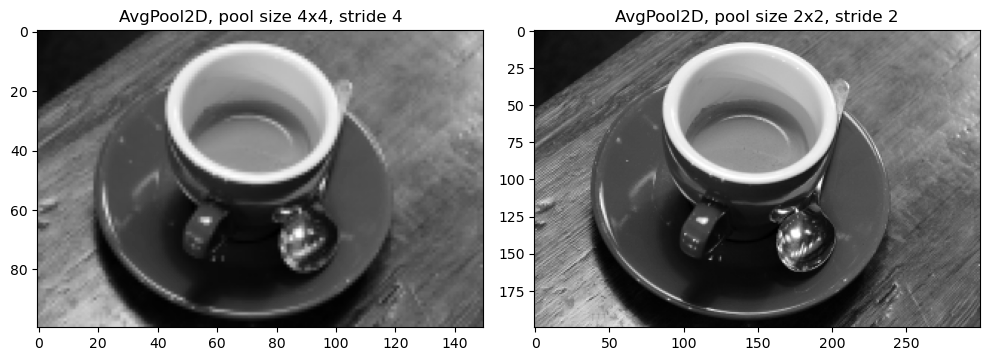

In [19]:
# CYC: I put two figures AvgPool2D with pool_size=(4, 4), strides=(4, 4) and with pool_size=(2, 2), strides=(2, 2) side by side to have a visual comparison

pool_AvgPool2D_4 = AvgPool2D(pool_size=(4, 4), strides=(4, 4), padding="valid")
pool_AvgPool2D_2 = AvgPool2D(pool_size=(2, 2), strides=(2, 2), padding="valid")

img_out_AP4 = pool_AvgPool2D_4(img_in)
img_out_AP2 = pool_AvgPool2D_2(img_in)

np_img_out_AP4 = img_out_AP4[0].numpy()
np_img_out_AP2 = img_out_AP2[0].numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("AvgPool2D, pool size 4x4, stride 4")
plt.imshow(np.squeeze(np_img_out_AP4.astype(np.uint8)), cmap=plt.cm.gray)

plt.subplot(1, 2, 2)
plt.title("AvgPool2D, pool size 2x2, stride 2")
plt.imshow(np.squeeze(np_img_out_AP2.astype(np.uint8)), cmap=plt.cm.gray)

plt.tight_layout()
plt.show()

> CYC notes:<br>
>
> From the above figures:<br>
>
> Looks like switching from (4×4) to (2×2) average pooling keeps more of the image's fine details and reduces blur, as does in max pooling (to me at lease visuall).<br>
>
> However in theory, average pooling acts like a balanced form of max pooling, keeping the overall contributions instead of emphasizing the strongest pixel only.<br>
> 
> Ref: https://www.quora.com/What-is-the-benefit-of-using-average-pooling-rather-than-max-pooling

> CYC notes:<br>
>
> Average pooling: calculates the mean of the elements within a sliding window >>> can be done with a convolution with a specific kernel.
>
> Max pooling: picks the largest number in the patch, which such choice depends on which pixel happens to be largest, so cannot be done by one kernel only.


## Loading a JPEG file as a numpy array

Let's use [scikit-image](http://scikit-image.rg) to load the content of a JPEG file into a numpy array:

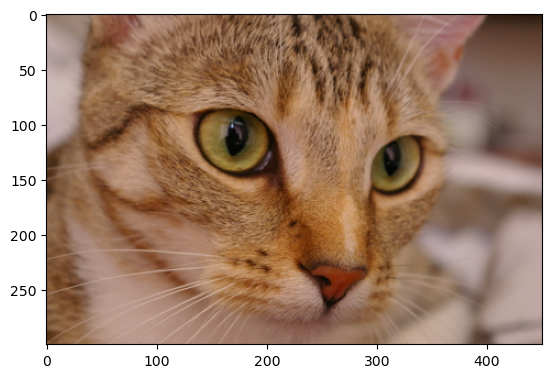

In [20]:
from skimage.io import imread

image = skimage.data.cat()
plt.imshow(image);

## Resizing images, handling data types and dynamic ranges

While convolutions can handle inputs of any size, it is often useful to resize images to a fixed size. This is particularly important for training deep learning models:

- for **image classification**, most networks expect a specific **fixed input size**;

- for **object detection** and instance segmentation, networks have more flexibility but the image should have **approximately the same size as the training set images**.

Furthermore **large images can be much slower to process** than smaller images (the number of pixels varies quadratically with the height and width).

In [21]:
from skimage.transform import resize

lowres_image = resize(image, (50, 50), mode='reflect', anti_aliasing=True)
    # shrinking the image to 50 pixels tall and 50 pixels wide.
    # mode='reflect': handles edge pixels by reflecting them, avoiding weird borders/jagged edges.
    # anti_aliasing=True: applies smoothing to reduce look rough during downsampling.

lowres_image.shape

(50, 50, 3)

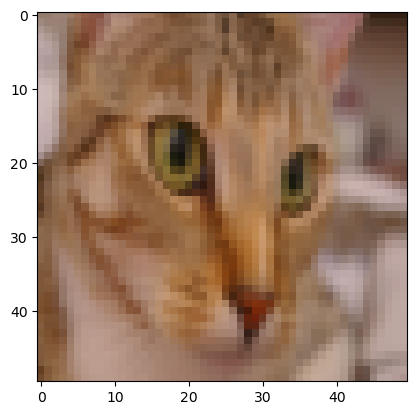

In [22]:
plt.imshow(lowres_image, interpolation='nearest');

The values of the pixels of the low resolution image are computed from by combining the values of the pixels in the high resolution image. The result is therefore represented as floating points.

## Using a pretrained model

Objectives:

- Load a pre-trained ResNet50 pre-trained model using Keras Zoo
- Use the model to classify an image
- Use the model to classify an image from the webcam

Let's start with loading ResNet50, a well-established method for image classification. The ResNet50 "application" takes two key parameters here: firstly, `include_top` indicates whether we want to include the last layer of the network (the classification layer) or not. Secondly, `weights` indicates whether we want to load the weights of a model that has been pre-trained on ImageNet or not.

In [23]:
from tensorflow.keras.applications.resnet50 import ResNet50

model = ResNet50(include_top=True, weights='imagenet')
    # include_top=True: loads the full model, including the final classification layer.
    # weights='imagenet': uses pretrained weights from the ImageNet dataset.

model.compile(optimizer='sgd', loss='categorical_crossentropy')

In [24]:
print(model.summary())

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


### Classification of an image

**Exercise**
- Reshape the `cat` image to the shape `(224, 224, 3)` using `resize` from `skimage.transform`
- Use `preprocess_input` from `tensorflow.keras.applications.imagenet_utils` to preprocess the image
- Use `predict` to classify the image

Documentation for each method:
- [resize](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize)
- [preprocess_input](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input)
- [predict](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)

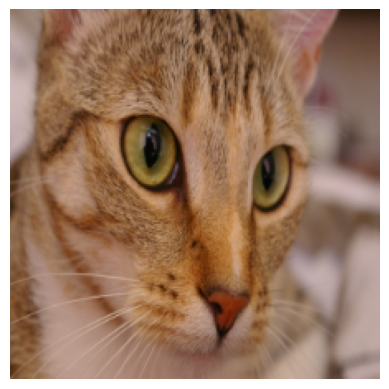

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted label: Egyptian_cat (95.70%)


In [25]:
from keras.applications.resnet50 import preprocess_input, decode_predictions

image_cat = skimage.data.cat()

image_cat_re = resize(image_cat, (224, 224), mode='reflect', anti_aliasing=True)

plt.imshow(image_cat_re)
plt.axis('off')
plt.show()

image_cat_in = np.expand_dims(image_cat_re.astype(np.float32), axis=0)

preprocessed_image = preprocess_input(image_cat_in*255)

model_cat = ResNet50(weights='imagenet')

predi_cat = model_cat.predict(preprocessed_image)

decoded = decode_predictions(predi_cat, top=1)[0][0]

print(f"Predicted label: {decoded[1]} ({decoded[2]*100:.2f}%)")


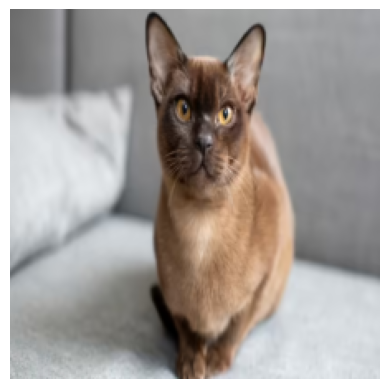

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted label: Siamese_cat (77.77%)


In [26]:
# CYC: just wanted to try one more cat figure!
from skimage.io import imread

image_cat2 = imread(r"D:\Figures\BurmeseCat.jpg") # source: https://animals.howstuffworks.com/pets/most-popular-cat-breeds.htm

image_cat_re2 = resize(image_cat2, (224, 224), mode='reflect', anti_aliasing=True)

plt.imshow(image_cat_re2)
plt.axis('off')
plt.show()

image_cat_in2 = np.expand_dims(image_cat_re2.astype(np.float32), axis=0)

preprocessed_image2 = preprocess_input(image_cat_in2*255)

model_cat2 = ResNet50(weights='imagenet') # loads pretrained weights

predi_cat2 = model_cat2.predict(preprocessed_image2)

decoded2 = decode_predictions(predi_cat2, top=1)[0][0]

print(f"Predicted label: {decoded2[1]} ({decoded2[2]*100:.2f}%)")

##  Taking snapshots from the webcam

For this section, we will take an image from your laptop webcam and classify it. If you feel uncomfortable doing this section, you can skip it and use a photo of your choice from the web instead.

> CYC notes:<br> 
> As Alex mentioned, this part is optional, so will skip using cv2 to grab an image and just use one from the web instead for now.<br> 

In [27]:
# import cv2

# def camera_grab(camera_id=0, fallback_filename=None):
#     camera = cv2.VideoCapture(camera_id)
#     try:
#         # take 10 consecutive snapshots to let the camera automatically tune
#         # itself and hope that the contrast and lighting of the last snapshot
#         # is good enough.
#         for i in range(10):
#             snapshot_ok, image = camera.read()
#         if snapshot_ok:
#             image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#         else:
#             print("WARNING: could not access camera")
#             if fallback_filename:
#                 image = imread(fallback_filename)
#     finally:
#         camera.release()
#     return image

In [28]:
# image = camera_grab(camera_id=0, fallback_filename=None)
# plt.imshow(image)
# print("dtype: {}, shape: {}, range: {}".format(image.dtype, image.shape, (image.min(), image.max())))

### Exercise

Apply the same preprocessing as before and classify the image. What are your results?

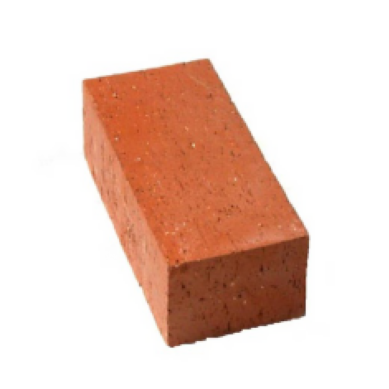

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted label: rubber_eraser (69.92%)


In [29]:
image_brick = imread(r"D:\Figures\Brick.jpg") # source: https://www.lowes.com/pd/Pacific-Clay-Common-Full-Red-Clay-Standard-Brick/4514218

image_brick_re = resize(image_brick, (224, 224), mode='reflect', anti_aliasing=True)

plt.imshow(image_brick_re)
plt.axis('off')
plt.show()

image_brick_in = np.expand_dims(image_brick_re.astype(np.float32), axis=0)

preprocessed_image3 = preprocess_input(image_brick_in*255)

model_brick = ResNet50(weights='imagenet') # loads pretrained weights

predi_brick = model_brick.predict(preprocessed_image3)

decoded3 = decode_predictions(predi_brick, top=1)[0][0]

print(f"Predicted label: {decoded3[1]} ({decoded3[2]*100:.2f}%)")